<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/CNN%20%2B%20LSTM%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [257]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [258]:
import os

RAW_DIR = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces"
PROCESSED_DIR = "/content/drive/MyDrive/Project/Project1/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

In [259]:
import os
import numpy as np

files = sorted([f for f in os.listdir(PROCESSED_DIR) if f.endswith(".npy")])

file_info = []

for f in files:
    path = os.path.join(PROCESSED_DIR, f)

    label = 0 if "NLOS" in f else 1

    # FIXED env extraction
    env = f.replace(".npy", "")

    file_info.append((path, label, env))

In [260]:
train_envs = [
    "channe14_LOS_cluster1",
    "channe14_LOS_cluster2",
    "channe14_NLOS_cluster1",
    "channe14_NLOS_cluster2",
    "channe14_NLOS_cluster3"
]

test_envs = [
    "channe14_LOS_cluster3",
    "channe14_LOS_cluster4",
    "channe14_NLOS_cluster4",
    "channe14_NLOS_cluster5"
]

In [261]:
for path, label, env in file_info:
    print(f"File: {os.path.basename(path)}")
    print(f"  Label: {label} ({'LOS' if label==1 else 'NLOS'})")
    print(f"  Env: {env}")
    print("-"*40)

File: channe14_LOS_cluster1.npy
  Label: 1 (LOS)
  Env: channe14_LOS_cluster1
----------------------------------------
File: channe14_LOS_cluster2.npy
  Label: 1 (LOS)
  Env: channe14_LOS_cluster2
----------------------------------------
File: channe14_LOS_cluster3.npy
  Label: 1 (LOS)
  Env: channe14_LOS_cluster3
----------------------------------------
File: channe14_LOS_cluster4.npy
  Label: 1 (LOS)
  Env: channe14_LOS_cluster4
----------------------------------------
File: channe14_NLOS_cluster1.npy
  Label: 0 (NLOS)
  Env: channe14_NLOS_cluster1
----------------------------------------
File: channe14_NLOS_cluster2.npy
  Label: 0 (NLOS)
  Env: channe14_NLOS_cluster2
----------------------------------------
File: channe14_NLOS_cluster3.npy
  Label: 0 (NLOS)
  Env: channe14_NLOS_cluster3
----------------------------------------
File: channe14_NLOS_cluster4.npy
  Label: 0 (NLOS)
  Env: channe14_NLOS_cluster4
----------------------------------------
File: channe14_NLOS_cluster5.npy
  L

In [262]:
def create_sequences(data, window_size=50, stride=10):
    sequences = []

    n = len(data)

    for i in range(0, n - window_size + 1, stride):
        sequences.append(data[i:i+window_size])

    return np.array(sequences)

In [263]:
X_train, y_train = [], []
X_test, y_test = [], []

for path, label, env in file_info:

    data = np.load(path)
    seqs = create_sequences(data, window_size=50, stride=10)

    if env in train_envs:
        X_train.append(seqs)
        y_train.append(np.full(len(seqs), label))

    elif env in test_envs:
        X_test.append(seqs)
        y_test.append(np.full(len(seqs), label))

In [264]:
for _, _, env in file_info:
    print(env)

channe14_LOS_cluster1
channe14_LOS_cluster2
channe14_LOS_cluster3
channe14_LOS_cluster4
channe14_NLOS_cluster1
channe14_NLOS_cluster2
channe14_NLOS_cluster3
channe14_NLOS_cluster4
channe14_NLOS_cluster5


In [265]:
for path, label, env in file_info:
    if env in train_envs:
        print(env, "→ TRAIN")
    elif env in test_envs:
        print(env, "→ TEST")
    else:
        print(env, "→ ❌ NOT MATCHED")

channe14_LOS_cluster1 → TRAIN
channe14_LOS_cluster2 → TRAIN
channe14_LOS_cluster3 → TEST
channe14_LOS_cluster4 → TEST
channe14_NLOS_cluster1 → TRAIN
channe14_NLOS_cluster2 → TRAIN
channe14_NLOS_cluster3 → TRAIN
channe14_NLOS_cluster4 → TEST
channe14_NLOS_cluster5 → TEST


In [266]:
for path, label, env in file_info:
    data = np.load(path)
    print(env, "frames:", len(data))

channe14_LOS_cluster1 frames: 8140
channe14_LOS_cluster2 frames: 8159
channe14_LOS_cluster3 frames: 8112
channe14_LOS_cluster4 frames: 8101
channe14_NLOS_cluster1 frames: 6081
channe14_NLOS_cluster2 frames: 4054
channe14_NLOS_cluster3 frames: 4058
channe14_NLOS_cluster4 frames: 4057
channe14_NLOS_cluster5 frames: 4063


In [267]:
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3027, 50, 72)
Test: (2416, 50, 72)


In [268]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [269]:
model = Sequential()

model.add(Conv1D(64, 3, activation='relu', input_shape=(50,72)))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# 🔥 stronger temporal learning
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64))

model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [270]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [271]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_22 (Conv1D)              │ (None, 48, 64)         │        13,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 48, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 22, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 22, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 11, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,465 (869.00 KB)

 Trainable params: 222,081 (867.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [272]:
EarlyStopping(
    monitor='val_loss',
    patience=5,   # increase slightly
    restore_best_weights=True
)

In [273]:
from sklearn.model_selection import train_test_split
# Split ONLY training data into train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train   # VERY IMPORTANT
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9793 - loss: 0.1264 - val_accuracy: 1.0000 - val_loss: 0.0395
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9959 - loss: 0.0498 - val_accuracy: 0.9719 - val_loss: 0.0898
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 1.0000 - loss: 0.0298 - val_accuracy: 1.0000 - val_loss: 0.0240


In [274]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8787 - loss: 0.3843
Test Accuracy: 0.8787251710891724


In [275]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


In [276]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.99      0.84       803
           1       1.00      0.82      0.90      1613

    accuracy                           0.88      2416
   macro avg       0.87      0.91      0.87      2416
weighted avg       0.91      0.88      0.88      2416



In [277]:
import numpy as np
print(np.bincount(y_train))
print(np.bincount(y_test))

[1125 1296]
[ 803 1613]


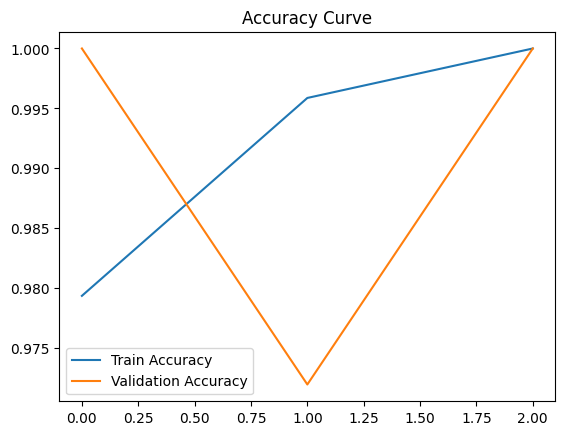

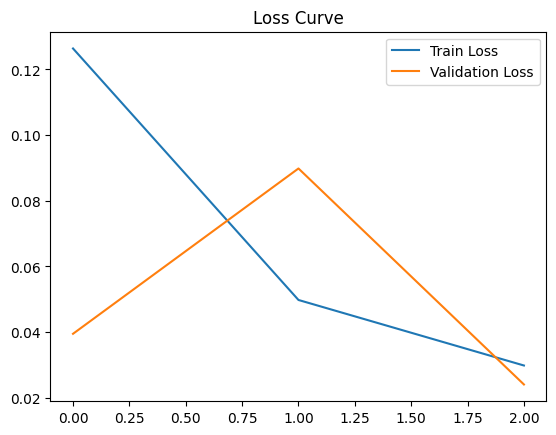

In [278]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()

In [279]:
loss, acc = model.evaluate(X_test, y_test)
print(acc)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8787 - loss: 0.3843
0.8787251710891724


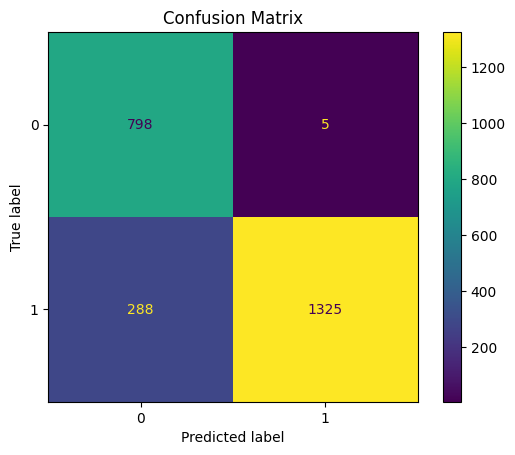

In [280]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


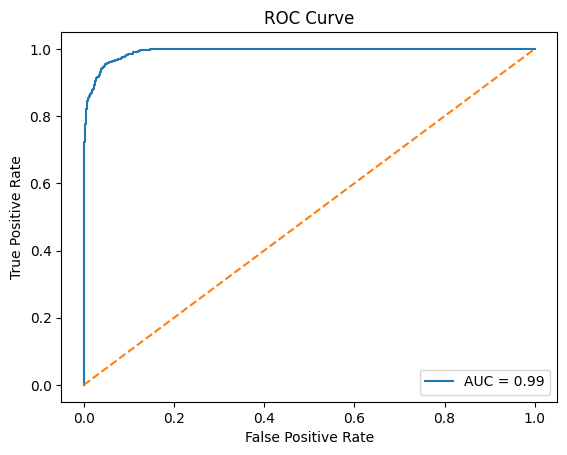

In [281]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ✅ Use X_test (NOT y_test)
y_prob = model.predict(X_test).ravel()

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()